# Proyek Klasifikasi Gambar: [Animal Face Dataset]
- **Nama:** [Meicha Salsabila Budiyanti]
- **Email:** [meichabudianti@gmail.com]
- **ID Dicoding:** [MC229D5X1101]

## Import Semua Packages/Library yang Digunakan

In [1]:
import os, shutil
import zipfile
import random
from random import sample
import shutil
from shutil import copyfile
import pathlib
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm as tq
import matplotlib.pyplot as plt

In [2]:
# Libraries untuk pemrosesan data gambar
import cv2
from PIL import Image
import skimage
from skimage import io
from skimage.transform import resize
from skimage.transform import rotate, AffineTransform, warp
from skimage import img_as_ubyte
from skimage.exposure import adjust_gamma
from skimage.util import random_noise

In [3]:
# Libraries untuk pembangunan model
import keras
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras import Model, layers
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras.layers import InputLayer, Conv2D, SeparableConv2D, MaxPooling2D, MaxPool2D, Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.applications.densenet import DenseNet121
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, Callback, EarlyStopping, ReduceLROnPlateau

In [4]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [5]:
# Mencetak versi TensorFlow yang sedang digunakan
print(tf.__version__)

2.18.0


## Data Preparation

### Data Loading

In [6]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"meichasalsa","key":"0c2e10e2159cf5ee56f1378516fb84cc"}'}

In [7]:
#Download kaggle datasets dan unzip
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d andrewmvd/animal-faces
!unzip animal-faces.zip

Streaming output truncated to the last 5000 lines.
  inflating: afhq/train/wild/flickr_wild_001378.jpg  
  inflating: afhq/train/wild/flickr_wild_001379.jpg  
  inflating: afhq/train/wild/flickr_wild_001380.jpg  
  inflating: afhq/train/wild/flickr_wild_001381.jpg  
  inflating: afhq/train/wild/flickr_wild_001382.jpg  
  inflating: afhq/train/wild/flickr_wild_001384.jpg  
  inflating: afhq/train/wild/flickr_wild_001385.jpg  
  inflating: afhq/train/wild/flickr_wild_001386.jpg  
  inflating: afhq/train/wild/flickr_wild_001387.jpg  
  inflating: afhq/train/wild/flickr_wild_001388.jpg  
  inflating: afhq/train/wild/flickr_wild_001389.jpg  
  inflating: afhq/train/wild/flickr_wild_001390.jpg  
  inflating: afhq/train/wild/flickr_wild_001391.jpg  
  inflating: afhq/train/wild/flickr_wild_001392.jpg  
  inflating: afhq/train/wild/flickr_wild_001393.jpg  
  inflating: afhq/train/wild/flickr_wild_001394.jpg  
  inflating: afhq/train/wild/flickr_wild_001395.jpg  
  inflating: afhq/train/wild/fl

In [8]:
import os
import shutil

In [9]:
#Direktori awal untuk train dan test
train_dir = "afhq/train"
test_dir = "afhq/val"

In [10]:
#Melihat direktori
os.listdir(train_dir)

['cat', 'wild', 'dog']

In [11]:
#Melihat direktori test
os.listdir(test_dir)

['cat', 'wild', 'dog']

In [12]:
#Direktori baru untuk dataset gabungan
combined_dir = "afhq/combined"

In [13]:
# Buat direktori baru untuk dataset gabungan
os.makedirs(combined_dir, exist_ok=True)

In [14]:
# Salin file dan folder dari train
for category in os.listdir(train_dir):
    category_dir = os.path.join(train_dir, category)
    if os.path.isdir(category_dir):
        shutil.copytree(category_dir, os.path.join(combined_dir, category), dirs_exist_ok=True)

# Salin file dan folder dari test
for category in os.listdir(test_dir):
    category_dir = os.path.join(test_dir, category)
    if os.path.isdir(category_dir):
        shutil.copytree(category_dir, os.path.join(combined_dir, category), dirs_exist_ok=True)

In [15]:
#Membuat kamus yang menyimpan gambar untuk setiap kelas dalam data
kamus_gambar = {}

In [16]:
#Tentukan path sumber train
path_train = "afhq/"
path_sub = os.path.join(path_train, "combined")
for i in os.listdir(path_sub):
  kamus_gambar[i] = os.listdir(os.path.join(path_sub, i))

In [17]:
#Menampilkan secara acak 5 gambar di bawah setiap dari 2 kelas data
#Melihat gambar yang berbeda setiap kali kode dijalankan
path_sub = "afhq/combined/"

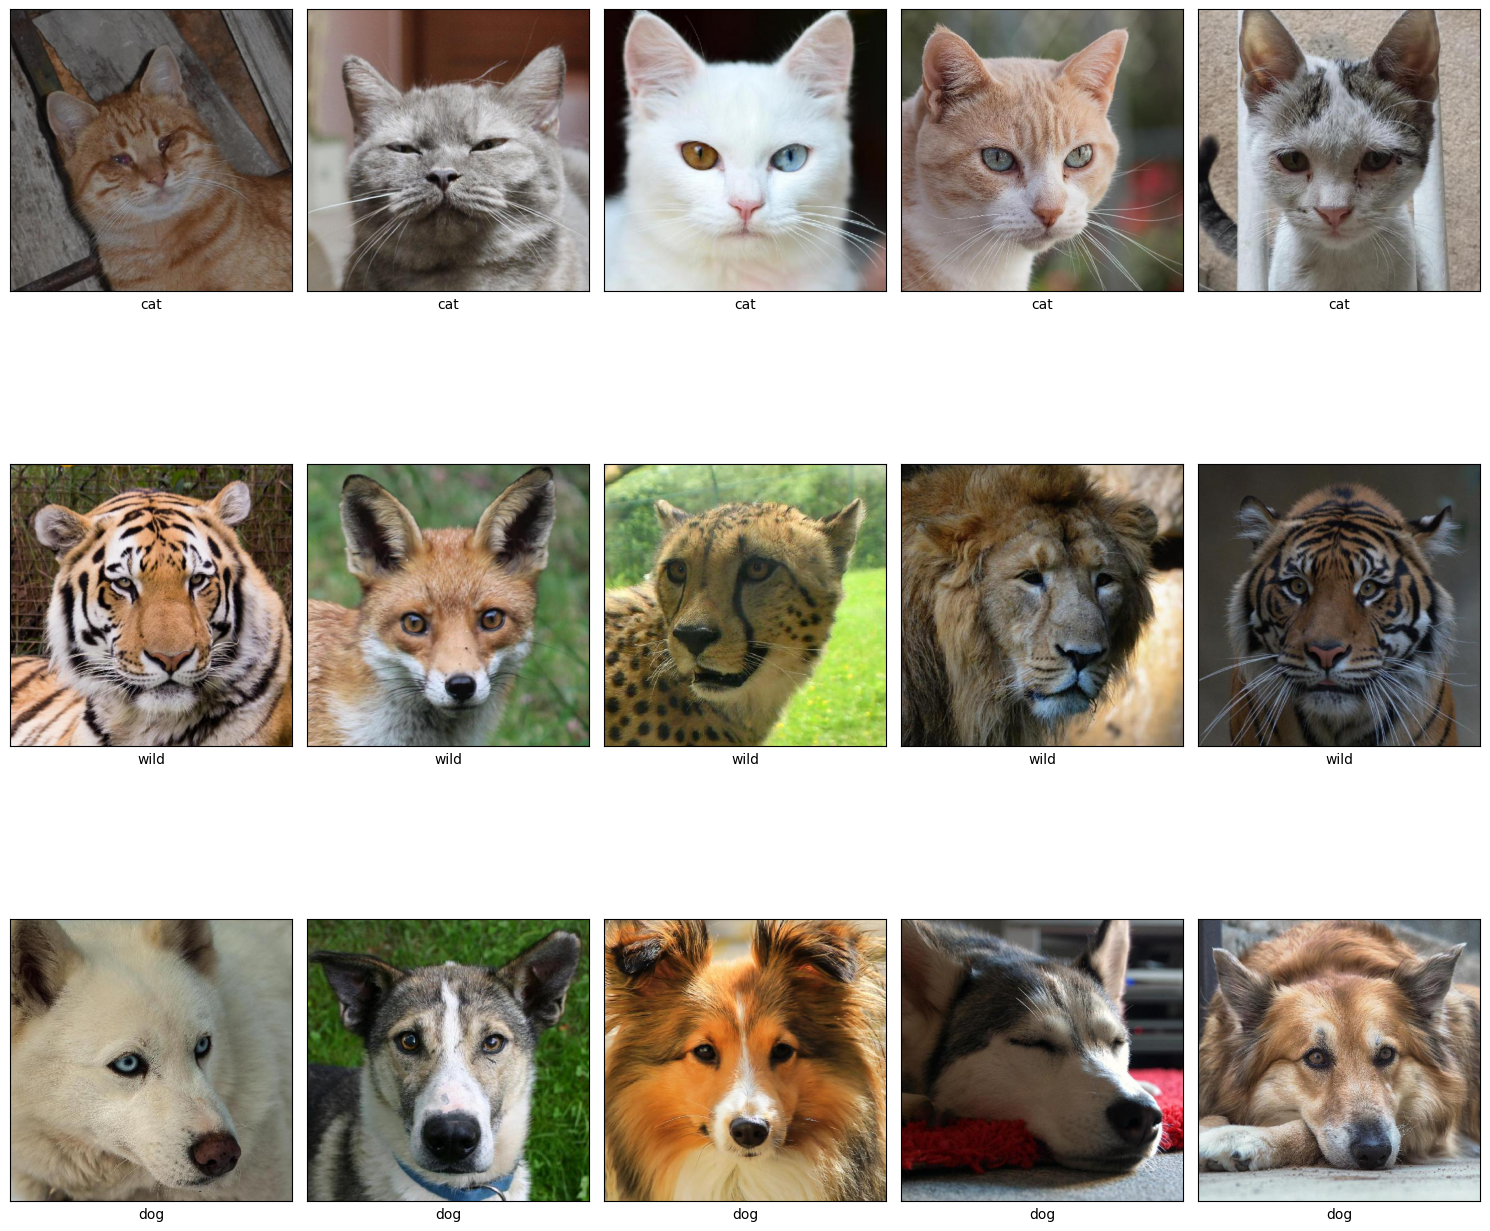

In [18]:
from PIL import Image

# Menampilkan secara acak 5 gambar di bawah setiap kelas dari data latih
fig, axs = plt.subplots(len(kamus_gambar), 5, figsize=(15, 15))

for i, class_name in enumerate(os.listdir(path_sub)):
    images = np.random.choice(kamus_gambar[class_name], 5, replace=False)

    for j, image_name in enumerate(images):
        img_path = os.path.join(path_sub, class_name, image_name)
        img = Image.open(img_path).convert("RGB")  # Tampilkan warna asli
        img = np.array(img)
        axs[i, j].imshow(img)
        axs[i, j].set(xlabel=class_name, xticks=[], yticks=[])

fig.tight_layout()
plt.show()


In [19]:
import seaborn as sns
#Mendefinisikan path sumber
path_lung = "afhq/combined/"

In [20]:
#Membuat daftar yang menyimpan data untuk setiap nama file, path file, dan label dalam dat
file_name = []
labels = []
full_path = []

In [21]:
#Mendapatkan nama file gambar, path file, dan label satu per satu dengan looping, dan simpan sebagai DataFrame
for path_train, subdirs, files in os.walk(path_lung):
    for name in files:
        full_path.append(os.path.join(path_train, name))
        labels.append(path_train.split("/")[-1])
        file_name.append(name)

distribution_train = pd.DataFrame({"path":full_path, 'file_name':file_name, "labels":labels})

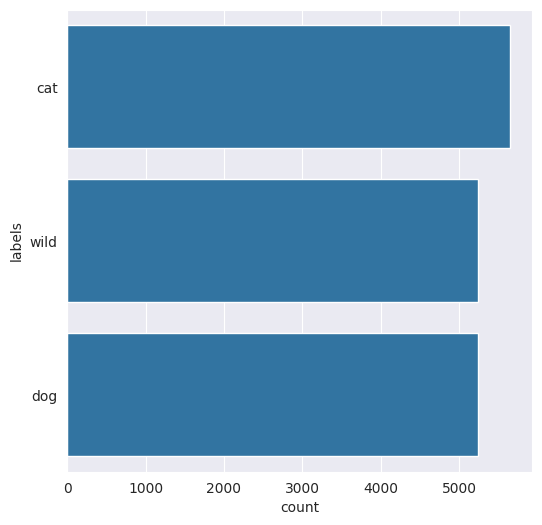

In [22]:
#Plot distribusi gambar disetiap kelas
Label = distribution_train['labels']
plt.figure(figsize = (6,6))
sns.set_style("darkgrid")
plot_data = sns.countplot(Label)

## Data Preprocessing

### Cheking Data

In [23]:
# Panggil variabel mypath yang menampung folder dataset gambar
mypath= 'afhq/combined/'

file_name = []
labels = []
full_path = []
for path, subdirs, files in os.walk(mypath):
    for name in files:
        full_path.append(os.path.join(path, name))
        labels.append(path.split('/')[-1])
        file_name.append(name)

# Memasukkan variabel yang sudah dikumpulkan pada looping di atas menjadi sebuah dataframe agar rapi
df = pd.DataFrame({"path":full_path,'file_name':file_name,"labels":labels})
# Melihat jumlah data gambar pada masing-masing label
df.groupby(['labels']).size()

,0
labels,
cat,5653
dog,5239
wild,5238


### Split Dataset

In [24]:
# Variabel yang digunakan pada pemisahan data ini di mana variabel x = data path dan y = data labels

X= df['path']
y= df['labels']

In [25]:
#Split dataset awal menjai data train, test, dan validasi
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

In [26]:
#Membagi daaset awal menjadi tiga bagian, yaitu data pelatihan (train), data uji (test), dan validasi
df_train = pd.DataFrame({'path': X_train, 'labels': y_train, 'set': 'train'})
df_test = pd.DataFrame({'path': X_test, 'labels': y_test, 'set':'test'})
df_val = pd.DataFrame({'path': X_val, 'labels': y_val, 'set' : 'val'})

In [27]:
#Melihat panjang DataFrame train, test, dan validasi
print(len(df_train))
print(len(df_test))
print(len(df_val))

10323
3226
2581


In [28]:
#Gabungkan DataFrame df_train, df_test, df_val
df_all = pd.concat([df_train, df_test, df_val], ignore_index=True)

print('===================================================== \n')
print(df_all.groupby(['set', 'labels']).size(), '\n')
print('===================================================== \n')


set    labels
test   cat       1119
       dog       1057
       wild      1050
train  cat       3604
       dog       3371
       wild      3348
val    cat        930
       dog        811
       wild       840
dtype: int64 




In [29]:
#Cek sampel data
df_all.sample(5)

,path,labels,set
1032,afhq/combined/dog/pixabay_dog_000968.jpg,dog,train
14809,afhq/combined/cat/pixabay_cat_003127.jpg,cat,val
14878,afhq/combined/dog/pixabay_dog_001733.jpg,dog,val
13179,afhq/combined/dog/pixabay_dog_001905.jpg,dog,test
7928,afhq/combined/wild/flickr_wild_002315.jpg,wild,train


In [30]:
# Memanggil dataset asli yang berisi keseluruhan data gambar yang sesuai dengan labelnya
datasource_path = "afhq/combined/"
# Membuat variabel Dataset, tempat menampung data yang telah dilakukan pembagian data training dan testing
dataset_path = "Dataset-Final/"

In [31]:
for index, row in tq(df_all.iterrows()):
    # Deteksi filepath
    file_path = row['path']
    if os.path.exists(file_path) == False:
            file_path = os.path.join(datasource_path,row['labels'],row['image'].split('.')[0])

    # Buat direktori tujuan folder
    if os.path.exists(os.path.join(dataset_path,row['set'],row['labels'])) == False:
        os.makedirs(os.path.join(dataset_path,row['set'],row['labels']))

    # Tentukan tujuan file
    destination_file_name = file_path.split('/')[-1]
    file_dest = os.path.join(dataset_path,row['set'],row['labels'],destination_file_name)

    # Salin file dari sumber ke tujuan
    if os.path.exists(file_dest) == False:
        shutil.copy2(file_path,file_dest)

0it [00:00, ?it/s]

## Modeling

In [32]:
#Mendefinisikan direktori training, test, dan validasi
TRAIN_DIR = "Dataset-Final/train/"
TEST_DIR = "Dataset-Final/test/"
VAL_DIR = "Dataset-Final/val/"

In [33]:
train_cat = os.path.join(TRAIN_DIR + '/cat')
train_dog = os.path.join(TRAIN_DIR + '/dog')
train_wild = os.path.join(TRAIN_DIR + '/wild')
test_wild = os.path.join(TEST_DIR + '/wild')
test_cat = os.path.join(TEST_DIR + '/cat')
test_dog = os.path.join(TEST_DIR + '/dog')
val_cat = os.path.join(VAL_DIR + '/cat')
val_dog = os.path.join(VAL_DIR + '/dog')
val_wild = os.path.join(VAL_DIR + '/wild')

In [34]:
print('total train cat images:', len(os.listdir(train_cat)))
print('total train dog images:', len(os.listdir(train_dog)))
print('total train wild images:', len(os.listdir(train_wild)))
print('total test cat images:', len(os.listdir(test_cat)))
print('total test dog images:', len(os.listdir(test_dog)))
print('total test wild images:', len(os.listdir(test_wild)))
print('total val cat images:', len(os.listdir(val_cat)))
print('total val dog images:', len(os.listdir(val_dog)))
print('total val wild images:', len(os.listdir(val_wild)))

total train cat images: 3604
total train dog images: 3371
total train wild images: 3348
total test cat images: 1119
total test dog images: 1057
total test wild images: 1050
total val cat images: 930
total val dog images: 811
total val wild images: 840


### Image Generator

In [35]:
#Membuat objek ImageDataGenerator yang menormalkan gambar
train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)
validation_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
        TRAIN_DIR,
        target_size=(224, 224),
        batch_size=32,
        class_mode='categorical',
        shuffle=True)

validation_generator = validation_datagen.flow_from_directory(
        VAL_DIR,
        target_size=(224, 224),
        batch_size=32,
        class_mode='categorical',
        shuffle=True)

test_generator = test_datagen.flow_from_directory(
        TEST_DIR,
        target_size=(224, 224),
        batch_size=32,
        class_mode='categorical',
        shuffle=False)

Found 10323 images belonging to 3 classes.
Found 2581 images belonging to 3 classes.
Found 3226 images belonging to 3 classes.


### Model

In [36]:
tf.keras.backend.clear_session()

####################### Init sequential model ##################################
model_1 = Sequential()

# ######################### Input layer with Fully Connected Layer ################################
# 1st Convolutional layer, Batch Normalization layer, and Pooling layer
model_1.add(Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(224,224,3)))
model_1.add(BatchNormalization())
model_1.add(MaxPool2D((2, 2)))

# 2nd Convolutional layer, Batch Normalization layer, and Pooling layer
model_1.add(Conv2D(32, (4, 4),padding='same', activation='relu'))
model_1.add(BatchNormalization())
model_1.add(MaxPool2D((2, 2)))

# 3rd Convolutional layer, Batch Normalization layer, and Pooling layer
model_1.add(Conv2D(32, (7, 7), padding='same', activation='relu'))
model_1.add(BatchNormalization())
model_1.add(MaxPool2D((2, 2)))

# Flatten layer
model_1.add(Flatten())
# 1nd Dense Layer
model_1.add(Dense(128, activation = 'relu'))
# 1nd Dropout Layer
model_1.add(Dropout(0.5))
# 2nd Dense Layer
model_1.add(Dense(64, activation = 'relu'))
# 2nd Dropout Layer
model_1.add(Dropout(0.3))

# Final Dense layer => For output prediction 1 mean (binary class in dataset), sigmoid for binary cases
model_1.add(Dense(3, activation='softmax'))
######################### Fully Connected Layer ################################

######################### Compile Model ################################
model_1.compile(optimizer=tf.keras.optimizers.RMSprop(),
                loss='categorical_crossentropy',
                metrics=['accuracy'])

# Summary of the Model Architecture
print(model_1.summary())

from tensorflow.keras.callbacks import Callback

# Callback
class CustomStopByAccuracyLoss(Callback):
    def on_epoch_end(self, epoch, logs=None):
        acc = logs.get("accuracy")
        loss = logs.get("loss")
        if acc is not None and loss is not None:
            if acc >= 0.95 and loss <= 0.1:
                print(f"\nTraining dihentikan karena accuracy >= 95% dan loss <= 0.1")
                self.model.stop_training = True

callbacks_list = CustomStopByAccuracyLoss()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 32)   │        16,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 32)     │        50,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,287,747 (12.54 MB)

 Trainable params: 3,287,555 (12.54 MB)

 Non-trainable params: 192 (768.00 B)

None


In [37]:
count_cat = len(os.listdir(train_cat))
count_dog = len(os.listdir(train_dog))
count_wild = len(os.listdir(train_wild))


In [38]:
total = count_cat + count_dog + count_wild

In [39]:
weight_cat = (1 / count_cat) * (total / 3.0)
weight_dog = (1 / count_dog) * (total / 3.0)
weight_wild = (1 / count_wild) * (total / 3.0)


In [40]:
train_generator.class_indices


{'cat': 0, 'dog': 1, 'wild': 2}

In [41]:
class_weights = {
    0: weight_cat,
    1: weight_dog,
    2: weight_wild
}


## Evaluasi dan Visualisasi

In [42]:
#Fitting / training model
history_1 = model_1.fit(train_generator,
                        epochs=30,
                        batch_size=32,
                        validation_data=validation_generator,
                        class_weight = class_weights,
                        callbacks=callbacks_list)

Epoch 1/30


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


323/323 ━━━━━━━━━━━━━━━━━━━━ 54s 142ms/step - accuracy: 0.5645 - loss: 3.7905 - val_accuracy: 0.6687 - val_loss: 1.1851
Epoch 2/30
323/323 ━━━━━━━━━━━━━━━━━━━━ 68s 119ms/step - accuracy: 0.8351 - loss: 0.5234 - val_accuracy: 0.9179 - val_loss: 0.2617
Epoch 3/30
323/323 ━━━━━━━━━━━━━━━━━━━━ 39s 120ms/step - accuracy: 0.9091 - loss: 0.2859 - val_accuracy: 0.9078 - val_loss: 0.2912
Epoch 4/30
323/323 ━━━━━━━━━━━━━━━━━━━━ 37s 114ms/step - accuracy: 0.9362 - loss: 0.2072 - val_accuracy: 0.9539 - val_loss: 0.1185
Epoch 5/30
323/323 ━━━━━━━━━━━━━━━━━━━━ 36s 111ms/step - accuracy: 0.9518 - loss: 0.1652 - val_accuracy: 0.8845 - val_loss: 0.6100
Epoch 6/30
323/323 ━━━━━━━━━━━━━━━━━━━━ 35s 108ms/step - accuracy: 0.9669 - loss: 0.1201 - val_accuracy: 0.9516 - val_loss: 0.1682
Epoch 7/30
323/323 ━━━━━━━━━━━━━━━━━━━━ 39s 122ms/step - accuracy: 0.9712 - loss: 0.1067 - val_accuracy: 0.9613 - val_loss: 0.1324
Epoch 8/30
323/323 ━━━━━━━━━━━━━━━━━━━━ 37s 113ms/step - accuracy: 0.9735 - loss: 0.1016 - val

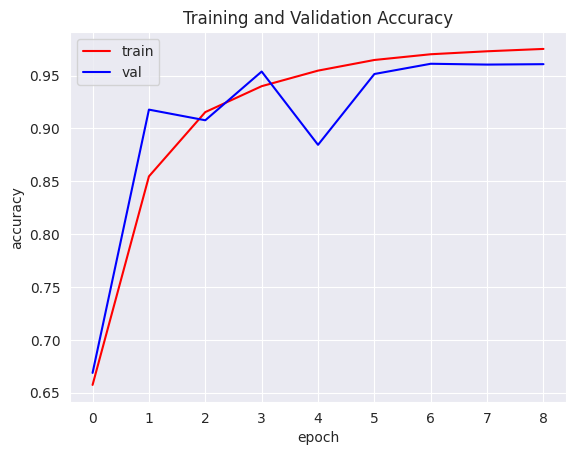

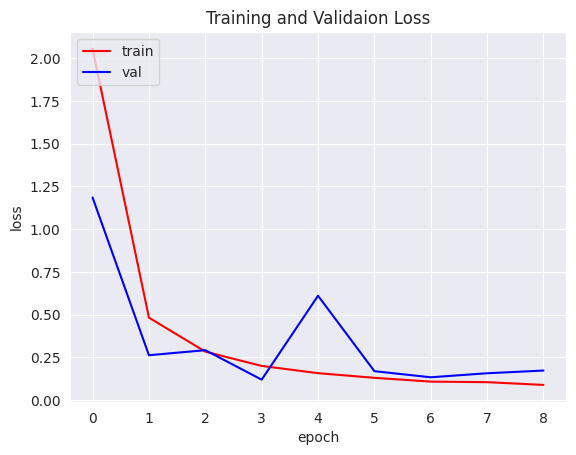

In [43]:
acc = history_1.history['accuracy']
val_acc = history_1.history['val_accuracy']
loss = history_1.history['loss']
val_loss = history_1.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'r')
plt.plot(epochs, val_acc, 'b')
plt.title('Training and Validation Accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

plt.plot(epochs, loss, 'r')
plt.plot(epochs, val_loss, 'b')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.title('Training and Validaion Loss')
plt.show()


Classification Report:

              precision    recall  f1-score   support

         Cat     0.9751    0.9786    0.9768      1119
         Dog     0.9859    0.9272    0.9556      1057
        Wild     0.9261    0.9781    0.9514      1050

    accuracy                         0.9616      3226
   macro avg     0.9623    0.9613    0.9613      3226
weighted avg     0.9627    0.9616    0.9616      3226



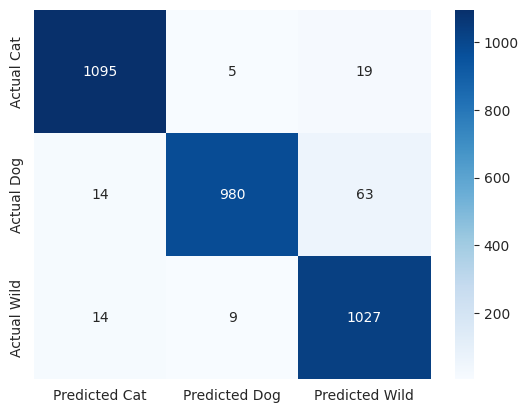

In [44]:
# Reset test generator (penting supaya urutan sesuai)
test_generator.reset()

# Predict with the model
preds_1 = model_1.predict(test_generator, verbose=0)

# Convert softmax output to class labels (ambil index dengan probabilitas tertinggi)
pred_labels = np.argmax(preds_1, axis=1)

# Confusion Matrix
cm = pd.DataFrame(
    data=confusion_matrix(test_generator.classes, pred_labels, labels=[0, 1, 2]),
    index=["Actual Cat", "Actual Dog", "Actual Wild"],
    columns=["Predicted Cat", "Predicted Dog", "Predicted Wild"]
)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

# Classification Report
print("\nClassification Report:\n")
print(classification_report(
    y_true=test_generator.classes,
    y_pred=pred_labels,
    target_names=['Cat', 'Dog', 'Wild'],
    digits=4
))

## Konversi Model

In [50]:
# Save model
os.makedirs('submission/saved_model', exist_ok=True)
model_1.export('submission/saved_model')

Saved artifact at 'submission/saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  138818950326288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138818950326672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138819033377168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138819033382160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138819033379088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138819033378320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138819033379664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138819033382736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138819033381776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138819032843280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13881903

In [51]:
!pip install tensorflowjs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.1/89.1 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 5.2 MB/s eta 0:00:00
  Attempting uninstall: packaging
    Found existing installation: packaging 24.2
    Uninstalling packaging-24.2:
      Successfully uninstalled packaging-24.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-cloud-bigquery 3.31.0 requires packaging>=24.2.0, but you have packaging 23.2 which is incompatible.


In [54]:
# tfjs_model
import tensorflowjs as tfjs
os.makedirs('submission/tfjs_model', exist_ok=True)
tfjs.converters.save_keras_model(model_1, 'submission/tfjs_model')

failed to lookup keras version from the file,
    this is likely a weight only file


In [55]:
# tflite
os.makedirs('submission/tflite', exist_ok=True)
converter = tf.lite.TFLiteConverter.from_saved_model('submission/saved_model')
tflite_model = converter.convert()
with open('submission/tflite/model.tflite', 'wb') as f:
    f.write(tflite_model)

# 4. Save label.txt
labels = list(test_generator.class_indices.keys())
with open('submission/tflite/label.txt', 'w') as f:
    for label in labels:
        f.write(f"{label}\n")

## Inference (Optional)